In [205]:
#Data Handling
import pandas as pd
import numpy as np
import joblib

#Data Visulization
import matplotlib.pyplot as plt
import seaborn as sns

#Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

#Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

#Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

#Ignore Warnings
import warnings
warnings.filterwarnings('ignore')




In [206]:
# Load the dataset

df = pd.read_csv("Health_Insurance.csv")

In [207]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [208]:
# Exploratory Data Analysis

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [209]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [210]:
# shape of the dataset
df.shape

(1338, 7)

In [211]:
# Check for missing values
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

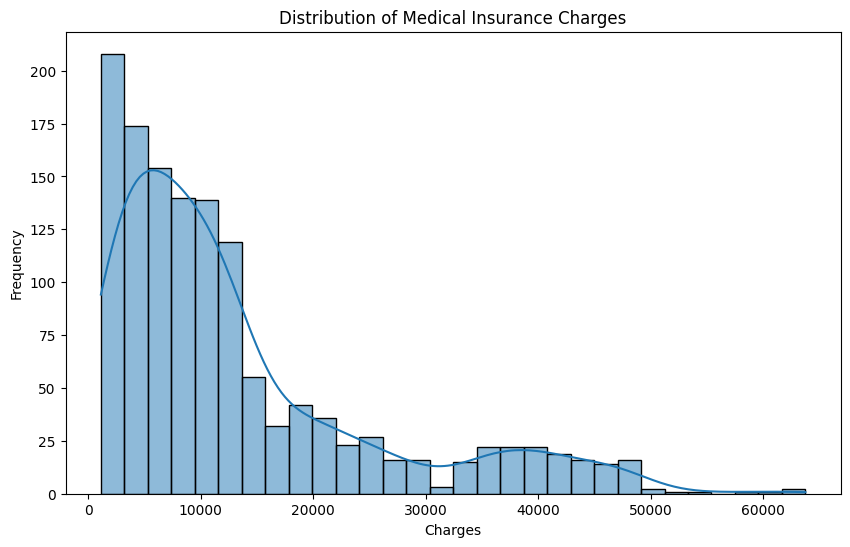

In [212]:
# visulaize the distribution of the target variable

plt.figure(figsize=(10, 6))
sns.histplot(df['charges'], kde=True)   
plt.title('Distribution of Medical Insurance Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.show()

Interpretation:

The distribution of medical insurance charges is positively  skewed, indicating that most individuals have relatively lower medical expenses while a small number of individuals incur very high insurance charges. The presence of extreme values suggests potential outliers in the dataset. Since the target variable is not normally distributed , wii have to apply log transformation, which may help improve model performance and stability.

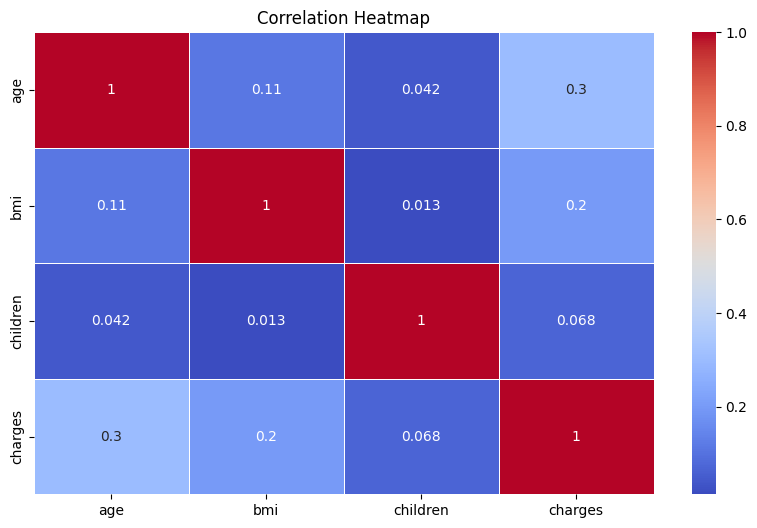

In [213]:
# Heatmap to visualize correlations

numeric_features = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_features.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

Interpretation:

The correlation heatmap shows the relationships among numerical variables in the dataset. Age has the highest positive correlation with insurance charges(0.30), indicating that medical expenses tend to increase with age. BMI also shows a weak positive correlation (0.20) with charges, suggesting that higher body mass index may lead to increased insurance costs. The number of children has very little impact on medical charges. Overall, no strong multicollinearity is observed among the numerical features.

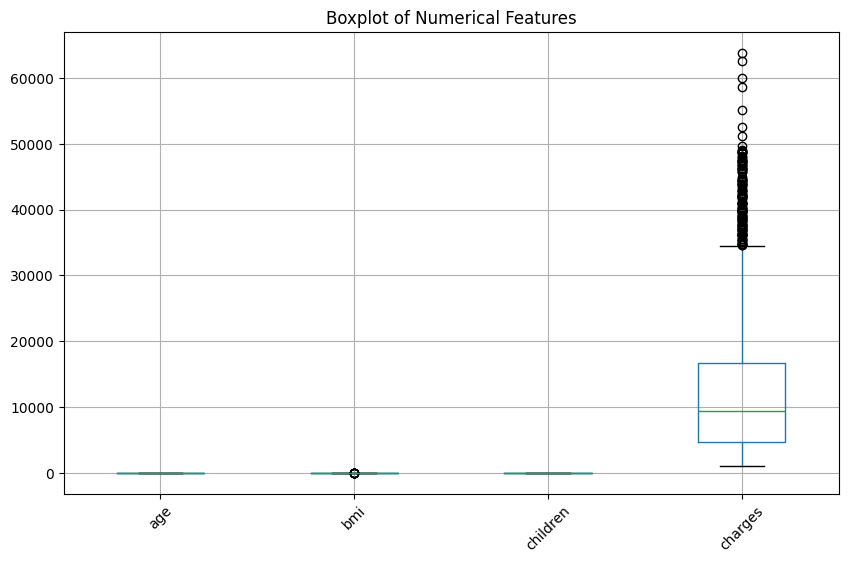

In [214]:
# Checking for outliers using boxplots

numeric_features = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 6))
numeric_features.boxplot()
plt.title('Boxplot of Numerical Features')
plt.xticks(rotation=45)
plt.show()

Interpretation:

The boxplot analysis reveals the presence of outliers primarily in the BMI and charges columns. The charges feature contains a large number of extreme values, indicating that some individuals incur significantly higher medical expenses than the majority of policyholders. Since these outliers may represent genuine high cost medical cases, log transformation is preferred over aggressive outlier removal to preserve important business information while reducing skewness and variance.

In [215]:
# Handle outlers using IQR method


for feature in numeric_features:
    Q1 = df["charges"].quantile(0.25)
    Q3 = df["charges"].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df["charges"] >= lower_bound) & (df["charges"] <= upper_bound)]

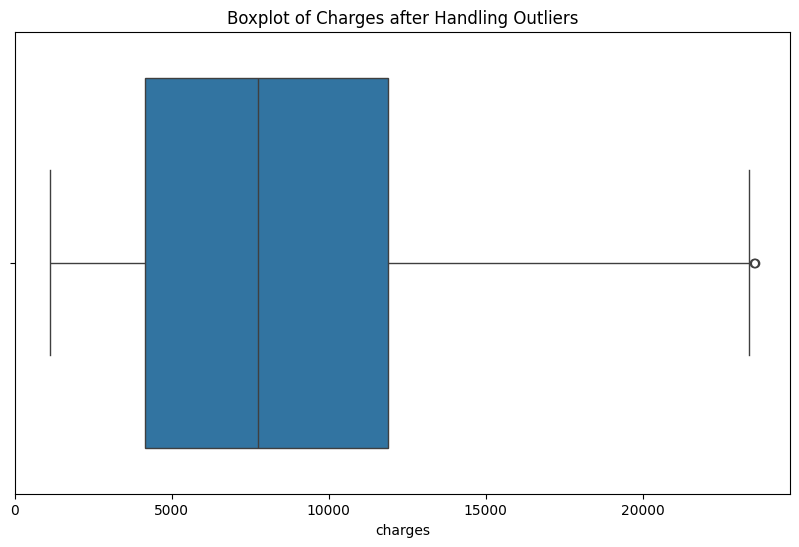

In [216]:
# box plot after handling outliers for charges

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['charges'])
plt.title('Boxplot of Charges after Handling Outliers')
plt.show()




In [217]:
# checking skewness
numeric_f = df.select_dtypes(include= np.number).columns.tolist()

skewness = df[numeric_f].skew()
print(skewness)

age         0.117620
bmi         0.346311
children    1.020775
charges     0.732624
dtype: float64


Interpretation:

Skewness analysis was performed on the numerical features to understand the distribution of the data. The target variable, charges showed moderate positive skewness with a skewness value of approximately 0.73. Since the skewness was not extremely high and the distribution was reasonably manageable, log transformation was not applied. Additionally tree based machine learning models such as Random Forest and Gradient Boosting are generally robust to moderately skewed data  and can perform well without transformation. Preserving the original target values also helps maintain interpretability of predicted insurance charges.

In [218]:
# Encode categorical variables

df = pd.get_dummies(df, drop_first=True)
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [219]:
# feature and target split

x = df.drop('charges', axis=1)
y = df['charges']

In [220]:
# Train Test Split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
#saving the model_columns
model_columns = x.columns
joblib.dump(x.columns.tolist(), "model_columns.pkl")

['model_columns.pkl']

In [222]:
# Feature Scaling

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)



In [223]:
# comparing the models

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),    
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Support Vector Regressor': SVR(),
    'K-Nearest Neighbors': KNeighborsRegressor()
}

In [224]:
result = []

for name, model in models.items():
    #train the model
    model.fit(x_train_scaled, y_train)

    
    #predictions
    y_train_pred = model.predict(x_train_scaled)
    y_test_pred = model.predict(x_test_scaled)

    #training metrics
    train_mse = mean_squared_error(y_train, y_train_pred)
    train_rmse = np.sqrt(train_mse)
    train_r2 = r2_score(y_train, y_train_pred)

    #testing metrics
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(y_test, y_test_pred)

    #Adjusted r2

    n = x_test_scaled.shape[0]
    p = x_test_scaled.shape[1]

    adjusted_r2 = 1 - ((1-test_r2)*(n-1)/(n-p-1))

    #overfitting
    if abs(train_r2 - test_r2) > 0.1:
        overfit = "Yes"
    else:
        overfit = "No"
        
    # append result
    result.append([
    name,
    train_mse,
    test_mse,
    train_rmse,
    test_rmse,
    train_r2,
    test_r2,
    adjusted_r2,
    overfit
])





   

In [225]:
# create dataframe

comparison_df = pd.DataFrame(result, columns=[
   "Model",
   "Train MSE",
   "Test MSE",
   "Train RMSE",
   "Test RMSE",
   "Train R2",
   "Test R2",
   "Adjusted R2",
   "Overfitting"

])

comparison_df

,Model,Train MSE,Test MSE,Train RMSE,Test RMSE,Train R2,Test R2,Adjusted R2,Overfitting
0,Linear Regression,9.560706e+06,6.940758e+06,3092.039109,2634.531776,0.676559,0.771269,0.762758,No
1,Decision Tree,2.049174e+05,1.928794e+07,452.677982,4391.803546,0.993068,0.364371,0.340720,Yes
2,Random Forest,1.639807e+06,8.916090e+06,1280.549394,2985.982206,0.944525,0.706173,0.695240,Yes
3,Gradient Boosting,6.312979e+06,8.109383e+06,2512.564251,2847.697821,0.786430,0.732757,0.722814,No
4,Support Vector Regressor,3.020347e+07,3.137875e+07,5495.768788,5601.673762,-0.021792,-0.034078,-0.072556,No
5,K-Nearest Neighbors,7.950661e+06,1.037016e+07,2819.691573,3220.273510,0.731027,0.658254,0.645538,No


Interpretation:

Multiple regression models were evaluated to predict medical insurance charges using both training and testing datasets. Among all the models, Linear Regression demonstrated the best overall performance with the lowest test RMSE(2634) and the highest Test R2 score(0.771), indicating strong predictive capability and good generalization on unseen data. Additionally, the model showed no signs of overfitting, as the training and testing performances remianed consistent.

Gradient Boosting also produced strong results and captured complex relationships within the dataset effectively, however its performance was slightly lower than Linear Regression and it lacked interpretability. Random Forest and Decision Tree models exhibited overfitting due to a large gap between training an testing performance , while Support Vector Regressor underperformed with a negative R2 score. K-Nearest Neighbour showed moderate predictive capability but was less effective compared to the top performing models.




In [226]:
#Hyperparameter tuning only for best model

rf = RandomForestRegressor(random_state = 42)

rf_params = {
    "n_estimators" :[100, 200, 300, 500],
    "max_depth" :[5,10,15,20,None],
    "min_samples_split" :[2,5,10],
    "min_samples_leaf" :[1,2,4],
    "bootstrap" :[True, False]

}

rf_random = RandomizedSearchCV(
    estimator= rf,
    param_distributions= rf_params,
    n_iter= 20,
    cv = 5,
    scoring = 'r2',
    n_jobs= -1,
    random_state= 42,
    verbose= 2

)

rf_random.fit(x_train_scaled, y_train)

print("\nRandom Forest Result")
print("Best Parameters:", rf_random.best_params_)
print("Best CV Score:", rf_random.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Random Forest Result
Best Parameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 5, 'bootstrap': True}
Best CV Score: 0.6669115178811624


In [227]:
# Gradient Boosting Tuning

gbr = GradientBoostingRegressor(random_state= 42)

gbr_params = {
    "n_estimators" : [100,200,300],
    "learning_rate" : [0.001 , 0.005, 0.1],
    "max_depth": [2,3,4],
    "subsample" : [0.8, 1.0]
}

gbr_grid = GridSearchCV(
    estimator=gbr,
    param_grid= gbr_params,
    cv = 5,
    scoring = "r2",
    n_jobs= -1,
    verbose = 2
)

gbr_grid.fit(x_train_scaled, y_train)

print("\nGradient Boosting Result")
print("Best Parameters:", gbr_grid.best_params_)
print("Best CV Score:", gbr_grid.best_score_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Gradient Boosting Result
Best Parameters: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100, 'subsample': 1.0}
Best CV Score: 0.6646443761955333


Interpretation:

Random Forest initially showed strong learning capability with a very high Train R2 score(0.94), but its Test R2 score (0.70) was significantly lower, indicating overfitting. This suggested that the model was capturing noise and memorizing training data rather than generalizing effectively on unseen data.

To reduce overfitting and improve generalization, hyperparameter tuning was performed using RandomizedSearchCV. Randomized Search was preferred beacuse Random Forest contains multiple hyperparameter and a very large search space. Instead of exhaustively testing every possible combination, RandomizedSearchCV samples a subset of parameter combinations randomly, making the tuning process computationally faster and more efficient while still identifying strong parameter settings.

The tuning focused on controlling model complexity through parameterssuch as:
* max_depth
* min_samples_split
* min_samples_leaf
* n_estimators

After tuning, its performance still remained lower than Linear Regression.


Gradient Boosting already demonstrated stable performance with no significant overfitting and achieved a relatively strong Test R2 score (0.73). Since the model was already performing well, a more systematic and exhaustive tuning approach was appropriate.

There GridSearchCV was used because the hyperparameter space for Gradient Boosting was smaller and more manageable compared to Random Forest. Grid Search evaluates all possible parameter combinations within the defined grid, allowing precise optimization of important parameters such as:

* learning_rate
* n_estimators
* max_depth
* subsample

The objective was to further improve predictive accuarcy while maintaining the model's stability and generalization capability.
Although Gradient Boosting produced competitive results after tuning, it still did not outperform Linear Regression.

In [228]:
# Train the model

lr = LinearRegression()
lr.fit(x_train_scaled, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Why Linear Regression:

Among all evaluated models, Linear Regression achieved the best overall performance with 

* Highest Test R2 Score(0.771)
* Lowest Test RMSE(2634)
* No signs of overfitting

The training and testing performances remained highly consistent, indicating that model generalized well to unseen data. This suggests that the relationship  between the independent variables and medical insurance charges in the dataset was largely linear.

Additionally, Linear Regression offered several practical advantage:

* Simpler and more interpretable model
* Faster training and prediction time
* Lower computational complexity
* Easier deployment and maintenance

Even after applying advanced ensemble techniques and hyperparameter tuning, complex models such as Random Forest and Gradient Boosting were unable to surpass the performance of Linear Regression. Therefore, Linear Regression was selected as the final model for deployment in the Medical Insurance Cost Prediction Sytem due to its accuracy, stability, efficiency and interpretability.



In [229]:
# save model 

joblib.dump(lr, "linear_regression_model.pkl")

['linear_regression_model.pkl']

In [230]:
# save scaler

joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']